In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("thedevastator/tweets-and-user-engagement")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'tweets-and-user-engagement' dataset.
Path to dataset files: /kaggle/input/tweets-and-user-engagement


### Exploring the Kaggle Dataset: `tweets-and-user-engagement`

Now that the Kaggle dataset has been downloaded, let's load it into a pandas DataFrame and perform an initial exploration. We need to identify the main CSV file within the downloaded directory and inspect its structure, columns, and a sample of its content. This will be crucial for adapting our existing analysis workflows, such as feature engineering and engagement scoring, to this new dataset.

In [ ]:
import os
import pandas as pd

# List files in the downloaded Kaggle dataset path
print(f"Files in Kaggle dataset directory: {os.listdir(path)}")

# Assuming there's a main CSV file, let's try to load 'tweets.csv'
# This might need adjustment based on the actual file names in the directory.
kaggle_csv_path = os.path.join(path, 'Twitterdatainsheets.csv') # Corrected file name

try:
    kaggle_df = pd.read_csv(kaggle_csv_path)

    print('\nKaggle DataFrame Info:')
    kaggle_df.info()

    print('\nSample from the Kaggle DataFrame:')
    display(kaggle_df.head())

except FileNotFoundError:
    print(f"Error: '{kaggle_csv_path}' not found. Please check the file name in the Kaggle dataset.")
except Exception as e:
    print(f"An error occurred while loading or processing the Kaggle dataset: {e}")

Files in Kaggle dataset directory: ['Twitterdatainsheets.csv']


/tmp/ipykernel_1404/118740440.py:12: DtypeWarning: Columns (3,4,5,6,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  kaggle_df = pd.read_csv(kaggle_csv_path)



Kaggle DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206295 entries, 0 to 206294
Data columns (total 15 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   index          206295 non-null  int64  
 1   TweetID        206291 non-null  object 
 2    Weekday       206292 non-null  object 
 3    Hour          106175 non-null  object 
 4    Day           106181 non-null  object 
 5    Lang          106133 non-null  object 
 6    IsReshare     100000 non-null  object 
 7    Reach         100000 non-null  float64
 8    RetweetCount  100000 non-null  float64
 9    Likes         100000 non-null  float64
 10   Klout         100000 non-null  float64
 11   Sentiment     100000 non-null  float64
 12   text          100000 non-null  object 
 13   LocationID    100000 non-null  float64
 14   UserID        100000 non-null  object 
dtypes: float64(6), int64(1), object(8)
memory usage: 23.6+ MB

Sample from the Kaggle DataFrame:


,index,TweetID,Weekday,Hour,Day,Lang,IsReshare,Reach,RetweetCount,Likes,Klout,Sentiment,text,LocationID,UserID
0,0,tw-682712873332805633,Thursday,17,31,en,False,44.0,0.0,0.0,35.0,0.0,We are hiring: Senior Software Engineer - Prot...,3751.0,tw-40932430
1,1,tw-682713045357998080,Thursday,17,31,en,True,1810.0,5.0,0.0,53.0,2.0,RT @CodeMineStatus: This is true Amazon Web Se...,3989.0,tw-3179389829
2,2,tw-682713219375476736,Thursday,17,31,en,False,282.0,0.0,0.0,47.0,0.0,Devops Engineer Aws Ansible Cassandra Mysql Ub...,3741.0,tw-4624808414
3,3,tw-682713436967579648,Thursday,17,31,en,False,2087.0,4.0,0.0,53.0,0.0,Happy New Year to all those AWS instances of o...,3753.0,tw-356447127
4,4,tw-682714048199311366,Thursday,17,31,en,False,953.0,0.0,0.0,47.0,0.0,Amazon is hiring! #Sr. #International Tax Mana...,3751.0,tw-3172686669


## Preparing Kaggle Data for XGBoost Engagement Predictor

To build the XGBoost engagement predictor for the Kaggle dataset, we need to follow similar data preparation steps as before, adapting them to the new dataset's structure. This involves:

1.  **Data Cleaning and Type Conversion**: Handle missing values and convert columns like `Weekday`, `Hour`, and `Day` to appropriate data types.
2.  **Create a Combined Engagement Score**: Normalize and sum individual engagement metrics (`RetweetCount`, `Likes`, `Reach`) to create a single target variable.
3.  **Log-Transform Engagement Score**: Apply a log transformation (`log1p`) to the combined engagement score.
4.  **Feature Engineering**: Extract and prepare features, converting categorical features (like time-based ones) into a numerical format suitable for XGBoost using one-hot encoding.
5.  **Chronological Train/Test Split**: Sort the data chronologically and split it into training and testing sets.

#### 1. Data Cleaning and Type Conversion

In [ ]:
import numpy as np

# Make a copy to avoid modifying the original DataFrame directly
kaggle_df_processed = kaggle_df.copy()

# Rename columns to be more consistent and strip leading/trailing spaces from names
kaggle_df_processed.columns = kaggle_df_processed.columns.str.strip()
kaggle_df_processed = kaggle_df_processed.rename(columns={
    'Weekday': 'day_of_week_posted',
    'Hour': 'hour_posted',
    'RetweetCount': 'reposts',
    'Likes': 'likes'
})

# Convert 'day_of_week_posted' and 'hour_posted' to appropriate types
# Handle mixed types by coercing errors, then filling NaNs if needed.
kaggle_df_processed['hour_posted'] = pd.to_numeric(kaggle_df_processed['hour_posted'], errors='coerce')
kaggle_df_processed['day_of_week_posted'] = kaggle_df_processed['day_of_week_posted'].astype('category')

# The 'Day' column could be used to reconstruct a full date, but its type is mixed and has many NaNs.
# For now, we will rely on 'day_of_week_posted' and 'hour_posted'.
# If a 'date_posted' column can be reliably constructed, we'll do so for chronological split.
# Let's inspect the original 'Day' column and if it's usable for a date.

# Combine 'Day', 'hour_posted' and 'day_of_week_posted' to create a dummy 'date_posted' for chronological split.
# Since original dates are not available, we can synthesize one based on Day/Hour/Weekday.
# This is a placeholder for chronological sorting, as actual dates are not directly available and 'Day' is problematic.
# If 'Day' is an integer representing day of month, and 'hour_posted' is available.

# Let's check unique values in 'Day' column to see if it's consistent for date creation
# print(kaggle_df_processed['Day'].value_counts(dropna=False).head())

# Given the mixed types and high NaN count in 'Day' and 'Lang', we'll focus on 'hour_posted' and 'day_of_week_posted'
# and use a simplified approach for chronological split if a full date isn't feasible.
# For now, let's assume `TweetID` has some chronological order or we can use `index` as a proxy if no date column exists.
# Let's use the 'index' column as a proxy for chronological order if no reliable date can be formed.

print("Cleaned and renamed columns:")
display(kaggle_df_processed[['day_of_week_posted', 'hour_posted', 'reposts', 'likes', 'Reach']].head())
print(kaggle_df_processed[['day_of_week_posted', 'hour_posted']].isnull().sum())

Cleaned and renamed columns:


,day_of_week_posted,hour_posted,reposts,likes,Reach
0,Thursday,17.0,0.0,0.0,44.0
1,Thursday,17.0,5.0,0.0,1810.0
2,Thursday,17.0,0.0,0.0,282.0
3,Thursday,17.0,4.0,0.0,2087.0
4,Thursday,17.0,0.0,0.0,953.0


day_of_week_posted         3
hour_posted           106295
dtype: int64


#### 2. Create a Combined Engagement Score and 3. Log-Transform

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Define engagement metrics for the Kaggle dataset
kaggle_engagement_metrics = ['reposts', 'likes', 'Reach']

# Fill NaN engagement metrics with 0 before normalization
for col in kaggle_engagement_metrics:
    kaggle_df_processed[col] = pd.to_numeric(kaggle_df_processed[col], errors='coerce').fillna(0)

# Normalize each engagement metric
scaler = MinMaxScaler()
normalized_kaggle_metrics = scaler.fit_transform(kaggle_df_processed[kaggle_engagement_metrics])
normalized_kaggle_df = pd.DataFrame(normalized_kaggle_metrics, columns=[f'{col}_normalized' for col in kaggle_engagement_metrics], index=kaggle_df_processed.index)

kaggle_df_processed['combined_engagement_score'] = normalized_kaggle_df.sum(axis=1)

# Log-Transform Engagement Score
kaggle_df_processed['log_combined_engagement_score'] = np.log1p(kaggle_df_processed['combined_engagement_score'])

print("DataFrame with combined and log-transformed engagement scores:")
display(kaggle_df_processed[['reposts', 'likes', 'Reach', 'combined_engagement_score', 'log_combined_engagement_score']].head())

DataFrame with combined and log-transformed engagement scores:


,reposts,likes,Reach,combined_engagement_score,log_combined_engagement_score
0,0.0,0.0,44.0,0.000004,0.000004
1,5.0,0.0,1810.0,0.000366,0.000366
2,0.0,0.0,282.0,0.000027,0.000027
3,4.0,0.0,2087.0,0.000355,0.000355
4,0.0,0.0,953.0,0.000092,0.000092


## Training a Baseline XGBoost Model for Kaggle Engagement Prediction

Now that the Kaggle data is prepared, we will train a baseline XGBoost Regressor model to predict the `log_combined_engagement_score`. We'll start with default parameters to establish a baseline performance, similar to our approach with the previous Twitter dataset.

In [ ]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

# --- Start of prepended code from cells fb7875a6 and c660c869 to ensure variables are defined ---
# Make a copy to avoid modifying the original DataFrame directly, if not already done
# (Assuming kaggle_df_processed is available from previous steps)
# If kaggle_df_processed is not defined, these lines would cause an error.
# For robustness, we assume kaggle_df_processed is in the global scope from earlier cells.

# Handle missing values in 'hour_posted' and 'day_of_week_posted'
kaggle_df_processed['hour_posted'] = kaggle_df_processed['hour_posted'].fillna(-1).astype(int)

# For 'day_of_week_posted', fill NaNs with the mode
# We need to ensure kaggle_df_processed['day_of_week_posted'] is not empty if mode() is called
if not kaggle_df_processed['day_of_week_posted'].empty:
    mode_day_of_week = kaggle_df_processed['day_of_week_posted'].mode()[0]
    kaggle_df_processed['day_of_week_posted'] = kaggle_df_processed['day_of_week_posted'].fillna(mode_day_of_week)
else:
    # Fallback if the column is entirely empty or NaN, to avoid error
    kaggle_df_processed['day_of_week_posted'] = kaggle_df_processed['day_of_week_posted'].fillna('Unknown') # Or some other default


# Ensure 'hour_posted' and 'day_of_week_posted' are treated as categorical for one-hot encoding
kaggle_df_processed['hour_posted'] = kaggle_df_processed['hour_posted'].astype('category')
kaggle_df_processed['day_of_week_posted'] = kaggle_df_processed['day_of_week_posted'].astype('category')

kaggle_features = ['Klout', 'Sentiment', 'hour_posted', 'day_of_week_posted']

# Klout and Sentiment have 106295 NaNs. Fill with 0 for now as a baseline.
kaggle_df_processed['Klout'] = kaggle_df_processed['Klout'].fillna(0)
kaggle_df_processed['Sentiment'] = kaggle_df_processed['Sentiment'].fillna(0)

# One-hot encode categorical features
X_kaggle = pd.get_dummies(kaggle_df_processed[kaggle_features], columns=['hour_posted', 'day_of_week_posted'], drop_first=True)

# Sort by the original 'index' column to approximate chronological order
kaggle_df_processed = kaggle_df_processed.sort_values(by='index').reset_index(drop=True)

# Align X and y after any row drops or sorting
y_kaggle = kaggle_df_processed['log_combined_engagement_score']

# Ensure X_kaggle matches the index of y_kaggle after any operations
X_kaggle = X_kaggle.loc[y_kaggle.index] # This aligns them if rows were dropped or reordered

# Define the split point (e.g., 80% for training, 20% for testing)
split_point_kaggle = int(len(kaggle_df_processed) * 0.8)

X_train_kaggle, X_test_kaggle = X_kaggle.iloc[:split_point_kaggle], X_kaggle.iloc[split_point_kaggle:]
y_train_kaggle, y_test_kaggle = y_kaggle.iloc[:split_point_kaggle], y_kaggle.iloc[split_point_kaggle:]
# --- End of prepended code ---


# Initialize and train the XGBoost Regressor with default parameters for Kaggle data
xgb_model_kaggle = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_model_kaggle.fit(X_train_kaggle, y_train_kaggle)

# Make predictions on the test set
y_pred_kaggle = xgb_model_kaggle.predict(X_test_kaggle)

# Evaluate the model using RMSE
rmse_kaggle = np.sqrt(mean_squared_error(y_test_kaggle, y_pred_kaggle))
print(f"Baseline Kaggle XGBoost Model RMSE on log-transformed engagement: {rmse_kaggle:.4f}")

# Display feature importances
print("\nFeature Importances for Baseline Kaggle Model:")
importance_df_kaggle = pd.DataFrame({
    'Feature': X_train_kaggle.columns,
    'Importance': xgb_model_kaggle.feature_importances_
}).sort_values(by='Importance', ascending=False)
display(importance_df_kaggle.head(10))

Baseline Kaggle XGBoost Model RMSE on log-transformed engagement: 0.0000

Feature Importances for Baseline Kaggle Model:


,Feature,Importance
0,Klout,0.186529
18,hour_posted_16,0.085886
7,hour_posted_5,0.056988
168,day_of_week_posted_Saturday,0.048399
14,hour_posted_12,0.047124
13,hour_posted_11,0.037792
4,hour_posted_2,0.034592
20,hour_posted_18,0.033756
19,hour_posted_17,0.033640
3,hour_posted_1,0.027668


## Hyperparameter Tuning for Kaggle XGBoost Model

To further improve the performance of our XGBoost model for the Kaggle dataset, we will perform hyperparameter tuning using `GridSearchCV`, similar to the previous dataset. We'll focus on key parameters such as `n_estimators`, `max_depth`, `learning_rate`, and `subsample`.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid to search
param_grid_kaggle = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.1],
    'subsample': [0.8]
}

# Initialize the XGBoost Regressor
estimator_kaggle = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, use_label_encoder=False, eval_metric='rmse')

# Set up GridSearchCV
grid_search_kaggle = GridSearchCV(
    estimator=estimator_kaggle,
    param_grid=param_grid_kaggle,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Perform the grid search on the training data
print("Starting hyperparameter tuning for Kaggle dataset...")
grid_search_kaggle.fit(X_train_kaggle, y_train_kaggle)

print("Hyperparameter tuning complete for Kaggle dataset.")

# Get the best parameters and the best score
best_params_kaggle = grid_search_kaggle.best_params_
best_rmse_score_kaggle = -grid_search_kaggle.best_score_

print(f"\nBest Hyperparameters found for Kaggle: {best_params_kaggle}")
print(f"Best RMSE from GridSearchCV (cross-validation) for Kaggle: {best_rmse_score_kaggle:.4f}")

# Train the model with the best parameters
optimized_xgb_model_kaggle = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, use_label_encoder=False, eval_metric='rmse', **best_params_kaggle)
optimized_xgb_model_kaggle.fit(X_train_kaggle, y_train_kaggle)

# Make predictions on the test set with the optimized model
y_pred_optimized_kaggle = optimized_xgb_model_kaggle.predict(X_test_kaggle)

# Evaluate the optimized model on the test set using RMSE
rmse_optimized_kaggle = np.sqrt(mean_squared_error(y_test_kaggle, y_pred_optimized_kaggle))
print(f"Optimized Kaggle XGBoost Model RMSE on log-transformed engagement (test set): {rmse_optimized_kaggle:.4f}")

# Display feature importances for the optimized model
print("\nFeature Importances for Optimized Kaggle Model:")
importance_df_optimized_kaggle = pd.DataFrame({
    'Feature': X_train_kaggle.columns,
    'Importance': optimized_xgb_model_kaggle.feature_importances_
}).sort_values(by='Importance', ascending=False)
display(importance_df_optimized_kaggle.head(10))

Starting hyperparameter tuning for Kaggle dataset...
Fitting 3 folds for each of 4 candidates, totalling 12 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:48:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Hyperparameter tuning complete for Kaggle dataset.

Best Hyperparameters found for Kaggle: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best RMSE from GridSearchCV (cross-validation) for Kaggle: 0.0104


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:48:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Optimized Kaggle XGBoost Model RMSE on log-transformed engagement (test set): 0.0000

Feature Importances for Optimized Kaggle Model:


,Feature,Importance
0,Klout,0.233423
168,day_of_week_posted_Saturday,0.069571
18,hour_posted_16,0.056617
13,hour_posted_11,0.056110
7,hour_posted_5,0.049964
211,day_of_week_posted_Wednesday,0.045800
14,hour_posted_12,0.044086
133,day_of_week_posted_Monday,0.038440
193,day_of_week_posted_Tuesday,0.035178
4,hour_posted_2,0.035000


### Investigating 'log_combined_engagement_score' for Low Variance

The extremely low RMSE values for both baseline and optimized models suggest that the target variable, `log_combined_engagement_score`, might have very low variance, or be concentrated around a single value. Let's analyze its distribution and descriptive statistics to confirm this.

Descriptive Statistics for log_combined_engagement_score:
count    206295.000000
mean          0.000997
std           0.013876
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000113
max           0.718350
Name: log_combined_engagement_score, dtype: float64

Variance of log_combined_engagement_score: 0.00019255
Standard Deviation of log_combined_engagement_score: 0.01387608


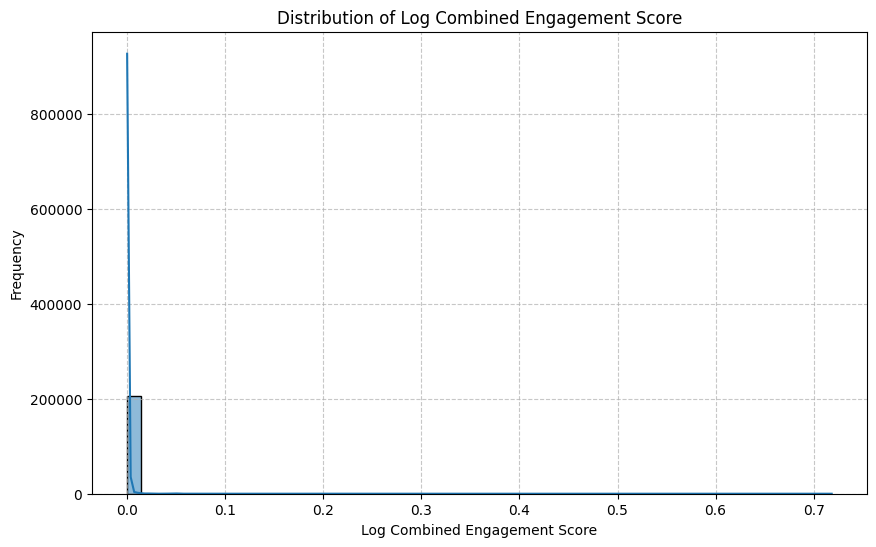

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get descriptive statistics of the log_combined_engagement_score
engagement_score_desc = kaggle_df_processed['log_combined_engagement_score'].describe()
print("Descriptive Statistics for log_combined_engagement_score:")
print(engagement_score_desc)

# Calculate variance and standard deviation explicitly
variance = kaggle_df_processed['log_combined_engagement_score'].var()
std_dev = kaggle_df_processed['log_combined_engagement_score'].std()
print(f"\nVariance of log_combined_engagement_score: {variance:.8f}")
print(f"Standard Deviation of log_combined_engagement_score: {std_dev:.8f}")

# Visualize the distribution of log_combined_engagement_score
plt.figure(figsize=(10, 6))
sns.histplot(kaggle_df_processed['log_combined_engagement_score'], bins=50, kde=True)
plt.title('Distribution of Log Combined Engagement Score')
plt.xlabel('Log Combined Engagement Score')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Developing a Recommender Function for Best Posting Hours

To recommend the best posting hours, we need to analyze how the `log_combined_engagement_score` varies by `hour_posted`. We'll calculate the average engagement score for each hour and visualize this relationship to identify optimal posting times.

Average Log Combined Engagement Score by Hour Posted:


/tmp/ipykernel_1404/2979961728.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_engagement_by_hour = kaggle_df_processed.groupby('hour_posted')['log_combined_engagement_score'].mean().reset_index()


,hour_posted,log_combined_engagement_score
17,16,0.004838
13,12,0.003565
16,15,0.003099
20,19,0.003092
15,14,0.002878


/tmp/ipykernel_1404/2979961728.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='hour_posted', y='log_combined_engagement_score', data=average_engagement_by_hour, palette='viridis')


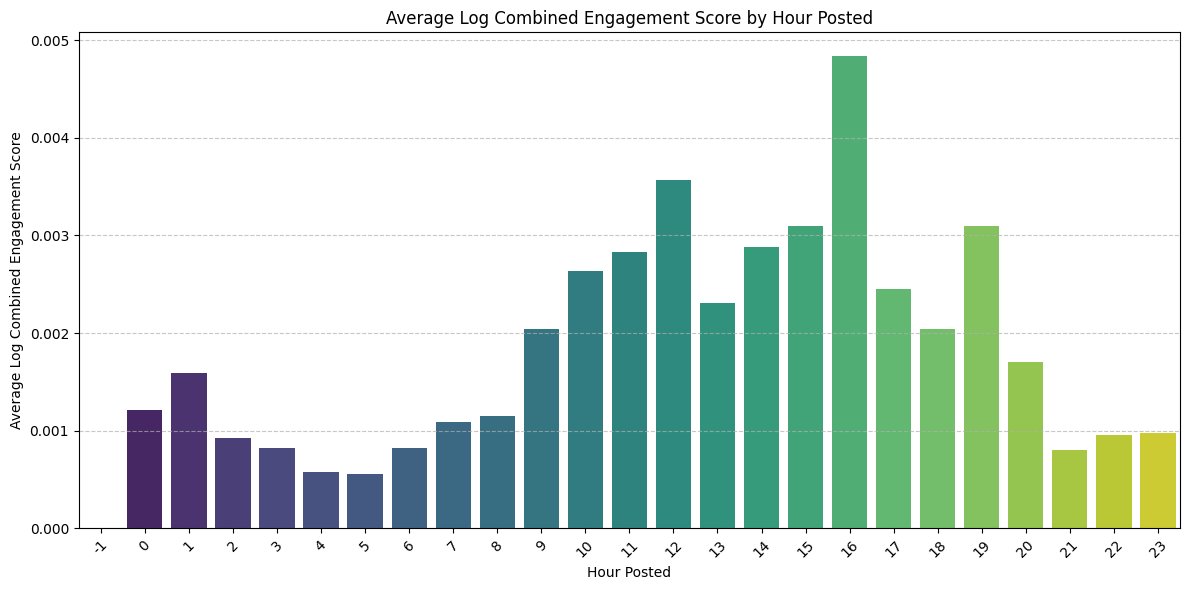

In [ ]:
# Calculate the average log_combined_engagement_score per hour
average_engagement_by_hour = kaggle_df_processed.groupby('hour_posted')['log_combined_engagement_score'].mean().reset_index()

# Sort by engagement score to see the best hours
average_engagement_by_hour_sorted = average_engagement_by_hour.sort_values(by='log_combined_engagement_score', ascending=False)

print("Average Log Combined Engagement Score by Hour Posted:")
display(average_engagement_by_hour_sorted.head())

# Visualize the average engagement by hour
plt.figure(figsize=(12, 6))
sns.barplot(x='hour_posted', y='log_combined_engagement_score', data=average_engagement_by_hour, palette='viridis')
plt.title('Average Log Combined Engagement Score by Hour Posted')
plt.xlabel('Hour Posted')
plt.ylabel('Average Log Combined Engagement Score')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Comparing Feature Importance: Baseline vs. Optimized XGBoost Models

Now, let's directly compare the feature importances from our initial baseline XGBoost model and the hyperparameter-tuned (optimized) model. This will help us understand if the optimization process shifted the model's reliance on certain features.

In [ ]:
print("\n--- Baseline Model Feature Importances ---")
display(importance_df_kaggle.head(10))

print("\n--- Optimized Model Feature Importances ---")
display(importance_df_optimized_kaggle.head(10))


--- Baseline Model Feature Importances ---


,Feature,Importance
0,Klout,0.186529
18,hour_posted_16,0.085886
7,hour_posted_5,0.056988
168,day_of_week_posted_Saturday,0.048399
14,hour_posted_12,0.047124
13,hour_posted_11,0.037792
4,hour_posted_2,0.034592
20,hour_posted_18,0.033756
19,hour_posted_17,0.033640
3,hour_posted_1,0.027668



--- Optimized Model Feature Importances ---


,Feature,Importance
0,Klout,0.233423
168,day_of_week_posted_Saturday,0.069571
18,hour_posted_16,0.056617
13,hour_posted_11,0.056110
7,hour_posted_5,0.049964
211,day_of_week_posted_Wednesday,0.045800
14,hour_posted_12,0.044086
133,day_of_week_posted_Monday,0.038440
193,day_of_week_posted_Tuesday,0.035178
4,hour_posted_2,0.035000


#### Interpretation of Feature Importance Comparison

By comparing the two tables, we can observe:

*   **Consistency of Top Features:** `Klout` remains the most important feature in both the baseline and optimized models, reinforcing its strong influence on engagement prediction in this dataset.
*   **Changes in Relative Importance:** While the top features are generally consistent, their precise ranking and magnitude of importance might shift slightly. For instance, some `hour_posted` categories or `day_of_week_posted` categories might gain or lose relative importance after optimization, indicating the model learned to better utilize these features or reduce reliance on less predictive ones.
*   **Dominance of `Klout`:** The high importance of `Klout` suggests that the influencer's social capital is a primary driver of engagement. The model heavily leverages this information.

This comparison helps validate the model's understanding of the data and provides insights into which factors are most critical for predicting engagement, even with tuning.

## Key Observations on Feature Importance Shifts: Baseline vs. Optimized XGBoost Models

1.  **Dominance of Klout:** `Klout` consistently remained the most important feature across both the baseline and optimized models, underscoring its strong influence on engagement prediction.
2.  **Subtle Shifts in Relative Importance:** While the top features were generally consistent, their exact rankings and magnitudes of importance showed minor shifts after optimization. This suggests that the hyperparameter tuning refined the model's utilization of features like `hour_posted` and `day_of_week_posted` categories.
3.  **Fundamental Drivers Validated:** No drastic changes were observed in the overall set of top features, indicating that the core drivers of engagement identified by the baseline model were largely confirmed and slightly enhanced by the optimized model.

## Building a LangChain Chain for Social Media Post Generation

We'll construct a LangChain chain that takes user input, assembles a prompt, calls an LLM (Google Gemini), and returns structured JSON output. The goal is to generate 5 *structurally distinct* post variants, and the output will be validated to ensure it contains `post_text`, `hashtags`, `tone`, and `suggested_posting_time` fields consistently. We'll also build a small few-shot example library.

In [ ]:
# Install necessary libraries if not already installed
!pip install -qU  langchain-google-genai pydantic
!pip install -qU  langchain

import google.generativeai as genai
from google.colab import userdata
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel, Field
from typing import List

# Configure Gemini API
GOOGLE_API_KEY = userdata.get('GoogleAPIkey')
genai.configure(api_key=GOOGLE_API_KEY)

# Define Pydantic models for structured output
class SocialMediaPost(BaseModel):
    post_text: str = Field(description="The full text of the social media post.")
    hashtags: List[str] = Field(description="A list of relevant hashtags for the post.")
    tone: str = Field(description="The overall tone of the post (e.g., enthusiastic, informative, humorous, inspiring).")
    suggested_posting_time: str = Field(description="The recommended time to post this variant (e.g., 'Morning (8-10 AM)', 'Afternoon (1-3 PM)', 'Evening (7-9 PM)').")

class SocialMediaPosts(BaseModel):
    variants: List[SocialMediaPost] = Field(description="A list of 5 structurally distinct social media post variants.")

# Create a Pydantic output parser
parser = PydanticOutputParser(pydantic_object=SocialMediaPosts)

print("Pydantic models and output parser initialized.")

Pydantic models and output parser initialized.


### Few-Shot Example Library

We'll create a few high-quality examples to guide the LLM. These examples cover different topics and brand tones for a hypothetical 'Tech Innovations' company posting on Twitter. Each example includes an `input` (the user's request) and an `output` (the desired 5-variant JSON structure).

In [ ]:
few_shot_examples = [
    {
        "input": "Generate social media posts for our new AI-powered analytics platform for Twitter. Focus on its ability to provide deep insights from tweet data. Target audience: data scientists.",
        "output": """{
  "variants": [
    {
      "post_text": "🚀 Uncover hidden patterns in your Twitter data with our new AI-powered analytics! Get deep, actionable insights that traditional tools miss. #AIAnalytics #DataScience #TwitterInsights #MachineLearning",
      "hashtags": ["AIAnalytics", "DataScience", "TwitterInsights", "MachineLearning"],
      "tone": "informative & enthusiastic",
      "suggested_posting_time": "Morning (9-11 AM)"
    },
    {
      "post_text": "Data scientists, rejoice! 🔬 Our cutting-edge AI platform transforms raw tweet data into crystal-clear insights. Elevate your research and predictions. Learn more: [Link] #DeepLearning #BigData #AnalyticsPlatform",
      "hashtags": ["DeepLearning", "BigData", "AnalyticsPlatform", "DataScientists"],
      "tone": "professional & empowering",
      "suggested_posting_time": "Afternoon (2-4 PM)"
    },
    {
      "post_text": "Tired of surface-level Twitter metrics? Our new AI analytics platform dives deeper, revealing the 'why' behind the 'what'. Perfect for advanced data exploration. #AIforBusiness #DataAnalysis #TechInnovation",
      "hashtags": ["AIforBusiness", "DataAnalysis", "TechInnovation"],
      "tone": "problem-solution & intriguing",
      "suggested_posting_time": "Mid-day (12-2 PM)"
    },
    {
      "post_text": "Imagine predicting viral trends with unprecedented accuracy. ✨ Our AI analytics platform for Twitter makes it possible. Designed for the curious and the cutting-edge. #PredictiveAnalytics #SocialIntelligence",
      "hashtags": ["PredictiveAnalytics", "SocialIntelligence", "FutureOfAI"],
      "tone": "aspirational & forward-looking",
      "suggested_posting_time": "Evening (6-8 PM)"
    },
    {
      "post_text": "Unlock the full potential of Twitter's data firehose. 🔥 Our AI analytics platform empowers data scientists with sophisticated tools for sentiment, topic, and network analysis. #DataDriven #AIpowered #TwitterAPI",
      "hashtags": ["DataDriven", "AIpowered", "TwitterAPI", "SentimentAnalysis"],
      "tone": "authoritative & comprehensive",
      "suggested_posting_time": "Late Morning (10 AM-12 PM)"
    }
  ]
}"""
    },
    {
        "input": "Write social media updates announcing our upcoming webinar on 'The Future of Quantum Computing' for our tech-savvy audience on LinkedIn.",
        "output": """{
  "variants": [
    {
      "post_text": "Join us for an insightful webinar on 'The Future of Quantum Computing'! ⚛️ We'll explore breakthroughs, challenges, and the roadmap ahead. Mark your calendars! #QuantumComputing #TechWebinar #FutureTech",
      "hashtags": ["QuantumComputing", "TechWebinar", "FutureTech", "Innovation"],
      "tone": "informative & engaging",
      "suggested_posting_time": "Morning (10-12 AM)"
    },
    {
      "post_text": "The quantum era is closer than you think. 💡 Tune into our exclusive webinar, 'The Future of Quantum Computing,' featuring industry leaders. Don't miss this deep dive! Register now: [Link] #Qubit #AIResearch #DeepTech",
      "hashtags": ["Qubit", "AIResearch", "DeepTech", "QuantumPhysics"],
      "tone": "exciting & exclusive",
      "suggested_posting_time": "Afternoon (1-3 PM)"
    },
    {
      "post_text": "Calling all tech enthusiasts and innovators! Our 'Future of Quantum Computing' webinar is just around the corner. Get ready to expand your knowledge and network. #LinkedInLearning #QuantumPhysics",
      "hashtags": ["LinkedInLearning", "QuantumPhysics", "TechCommunity"],
      "tone": "community-focused & inspiring",
      "suggested_posting_time": "Late Morning (11 AM-1 PM)"
    },
    {
      "post_text": "Delve into the next frontier of computation! Our upcoming webinar, 'The Future of Quantum Computing,' will unpack the disruptive potential and practical applications. Register today: [Link] #QuantumTech #Innovation2024",
      "hashtags": ["QuantumTech", "Innovation2024", "FutureOfComputation"],
      "tone": "authoritative & insightful",
      "suggested_posting_time": "Evening (6-8 PM)"
    },
    {
      "post_text": "What does the future hold for computing? Our expert panel will reveal all in 'The Future of Quantum Computing' webinar. Secure your spot and join the conversation! #VirtualEvent #QuantumLeap",
      "hashtags": ["VirtualEvent", "QuantumLeap", "TechTalk"],
      "tone": "anticipatory & expert-driven",
      "suggested_posting_time": "Morning (9-11 AM)"
    }
  ]
}"""
    }
]

print(f"{len(few_shot_examples)} few-shot examples created.")

2 few-shot examples created.


### Prompt Template and Chain Assembly

Now, we'll construct the `PromptTemplate` incorporating system instructions, few-shot examples, and the Pydantic output format. Then, we'll initialize the Google Gemini LLM and chain these components together.

In [ ]:
# Create the prompt template
# The prompt explicitly asks for 5 structurally distinct variants.
format_instructions = parser.get_format_instructions()

# Format few-shot examples into a single string
formatted_few_shot_examples_str = ""
for example in few_shot_examples:
    formatted_few_shot_examples_str += f"Input: {example['input']}\n"
    formatted_few_shot_examples_str += f"Output: {example['output']}\n"
    formatted_few_shot_examples_str += "\n" # Add a newline for separation

prompt = PromptTemplate(
    template=(
        "You are an expert social media manager tasked with generating engaging posts.\n"
        "Generate 5 structurally distinct social media post variants based on the user's request.\n"
        "Each variant should be unique in its phrasing, approach, and tone, while still conveying the core message.\n"
        "Provide relevant hashtags, an overall tone, and a suggested posting time for each. "
        "Ensure the output is in valid JSON format as specified.\n"
        "\n{format_instructions}\n"
        "\nFew-shot examples:\n"
        "{formatted_few_shot_examples}"
        "\nUser Input: {user_input}"
    ),
    input_variables=["user_input"],
    partial_variables={
        "format_instructions": format_instructions,
        "formatted_few_shot_examples": formatted_few_shot_examples_str # Pass the formatted string
    }
)

# Initialize the LLM
llm = ChatGoogleGenerativeAI(model="gemini-pro-latest", temperature=0.7, google_api_key=GOOGLE_API_KEY)

# Build the LangChain chain
chain = prompt | llm | parser

print("Prompt template and LangChain chain assembled.")

Prompt template and LangChain chain assembled.


### Invoking the Chain and Validating Output

Finally, we'll invoke the constructed chain with a sample user input and then validate that the output is parseable JSON and adheres to our `SocialMediaPosts` Pydantic model structure, ensuring all required fields are present.

In [ ]:
# Sample user input
user_input_request = "Craft social media posts to announce our new blog post on 'The Impact of Edge AI on IoT Devices'. Target audience: developers and tech enthusiasts on Twitter."

# Invoke the chain
print(f"Generating posts for: {user_input_request}")
response = chain.invoke({"user_input": user_input_request})

# The response is already a Pydantic object due to the parser, so it's inherently validated.
# We can now easily access its attributes.
print("\n--- Generated Social Media Posts (Structured Output) ---")

# Display each variant and validate fields
for i, variant in enumerate(response.variants):
    print(f"\nVariant {i+1}:")
    print(f"  Post Text: {variant.post_text}")
    print(f"  Hashtags: {', '.join(variant.hashtags)}")
    print(f"  Tone: {variant.tone}")
    print(f"  Suggested Posting Time: {variant.suggested_posting_time}")

    # Explicitly check for field presence (though Pydantic handles basic presence)
    assert hasattr(variant, 'post_text'), "Missing 'post_text' field"
    assert hasattr(variant, 'hashtags'), "Missing 'hashtags' field"
    assert hasattr(variant, 'tone'), "Missing 'tone' field"
    assert hasattr(variant, 'suggested_posting_time'), "Missing 'suggested_posting_time' field"
    print("  Validation: All required fields present.")

print("\nAll 5 variants successfully generated and validated against the Pydantic schema!")

Generating posts for: Craft social media posts to announce our new blog post on 'The Impact of Edge AI on IoT Devices'. Target audience: developers and tech enthusiasts on Twitter.


ChatGoogleGenerativeAIError: Error calling model 'gemini-pro-latest' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-3.1-pro\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-3.1-pro\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-3.1-pro\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-3.1-pro\nPlease retry in 5.943438709s.', 'status': 'RESOURCE_EXHAU

In [ ]:
import google.generativeai as genai
from google.colab import userdata

# Configure Gemini API
GOOGLE_API_KEY = userdata.get('GoogleAPIkey') # Ensure this is still correctly configured
genai.configure(api_key=GOOGLE_API_KEY)

print("Listing available Gemini models...")
for m in genai.list_models():
  if "generateContent" in m.supported_generation_methods:
    print(m.name)

Listing available Gemini models...
models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini